#### GoEmotions Data Analysis

Phân tích đặc điểm của GoEmotions trước khi xây dựng model:
- Label frequency và imbalance.
- Label cardinality.
- Text length.
- Label co-occurrence.
- Broad distribution shift giữa train và validation.


In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import DatasetDict, load_dataset


sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if not (
    PROJECT_ROOT / "data" / "artifacts" / "dataset_contract.json"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CONTRACT_PATH = (
    PROJECT_ROOT
    / "data"
    / "artifacts"
    / "dataset_contract.json"
)

if not CONTRACT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset contract not found: {CONTRACT_PATH}"
    )

# luu file json audit vao bien contract, sau do lay ra cac phan va luu vao cac bien sau
contract = json.loads(
    CONTRACT_PATH.read_text(encoding="utf-8")
)

if contract["validation"]["status"] != "passed":
    raise ValueError(
        "Dataset contract has not passed validation"
    )

dataset_name = contract["dataset"]["source"]
dataset_config = contract["dataset"]["config"]
label_names = contract["schema"]["label_names"]

official_dataset = load_dataset(
    dataset_name,
    dataset_config,
)

# check xem da dung fingerprint chua
for split_name in ("train", "validation", "test"):
    expected_fingerprint = contract["official_splits"][
        split_name
    ]["fingerprint"]
    actual_fingerprint = official_dataset[
        split_name
    ]._fingerprint

    if actual_fingerprint != expected_fingerprint:
        raise ValueError(
            f"{split_name} fingerprint changed: "
            f"{actual_fingerprint} != {expected_fingerprint}"
        )

clean_splits = {}
split_policy = contract["evaluation_policy"]["splits"]

# tao lai 1 clean dataset cho cac split tu excluded id sau khi audit
for split_name in ("train", "validation", "test"):
    excluded_ids = set(
        split_policy[split_name]["excluded_ids"]
    )
    official_ids = set(
        official_dataset[split_name]["id"]
    )

    missing_excluded_ids = excluded_ids - official_ids

    if missing_excluded_ids:
        raise ValueError(
            f"{split_name} is missing excluded IDs: "
            f"{sorted(missing_excluded_ids)}"
        )

    keep_indices = [
        index
        for index, row_id in enumerate(
            official_dataset[split_name]["id"]
        )
        if row_id not in excluded_ids
    ]

    clean_splits[split_name] = official_dataset[
        split_name
    ].select(keep_indices)

clean_dataset = DatasetDict(clean_splits)


split_rows = []
# dem xem so row hien tai dc clean da dung vs ban dau chua
for split_name in ("train", "validation", "test"):
    expected_rows = split_policy[split_name][
        "clean_num_rows"
    ]
    actual_rows = len(clean_dataset[split_name])

    if actual_rows != expected_rows:
        raise ValueError(
            f"{split_name} clean size changed: "
            f"{actual_rows} != {expected_rows}"
        )

    # 1 list chua dict thong tin cua cac split
    split_rows.append(
        {
            "split": split_name,
            "official_rows": len(
                official_dataset[split_name]
            ),
            "clean_rows": actual_rows,
            "excluded_rows": (
                len(official_dataset[split_name])
                - actual_rows
            ),
        }
    )

# check xem sau khi clean dataset thi giua 2 split con bi trung text nao khong
clean_text_sets = {
    split_name: set(clean_dataset[split_name]["text"])
    for split_name in ("train", "validation", "test")
}
for left_split, right_split in combinations(
    ("train", "validation", "test"),
    2,
):
    shared_text_count = len(
        clean_text_sets[left_split]
        & clean_text_sets[right_split]
    )

    if shared_text_count != 0:
        raise ValueError(
            f"{left_split} and {right_split} still share "
            f"{shared_text_count} exact texts"
        )

split_summary = pd.DataFrame(split_rows)
display(split_summary)

,split,official_rows,clean_rows,excluded_rows
0,train,43410,43410,0
1,validation,5426,5383,43
2,test,5427,5385,42


In [3]:
analysis_frames = {}

for split_name in ("train", "validation"):
    split = clean_dataset[split_name]

    frame = pd.DataFrame(
        {
            "id": list(split["id"]),
            "text": list(split["text"]),
            "labels": [
                list(label_ids)
                for label_ids in split["labels"]
            ],
        }
    )

    frame["label_cardinality"] = frame[
        "labels"
    ].map(len)
    frame["word_count"] = (
        frame["text"]
        .str.split()
        .str.len()
    )

    analysis_frames[split_name] = frame

train_df = analysis_frames["train"]
validation_df = analysis_frames["validation"]

frame_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "num_rows": len(frame),
            "minimum_cardinality": frame[
                "label_cardinality"
            ].min(),
            "maximum_cardinality": frame[
                "label_cardinality"
            ].max(),
            "minimum_word_count": frame[
                "word_count"
            ].min(),
            "maximum_word_count": frame[
                "word_count"
            ].max(),
        }
        for split_name, frame in analysis_frames.items()
    ]
)

display(frame_summary)

,split,num_rows,minimum_cardinality,maximum_cardinality,minimum_word_count,maximum_word_count
0,train,43410,1,5,1,33
1,validation,5383,1,4,1,30


#### Target distribution

Phần này phân tích:

1. Support và prevalence của từng label.
2. Mức mất cân bằng giữa label phổ biến và label hiếm.
3. Số positive labels trên mỗi sample.
4. Broad label-distribution shift giữa train và validation.



,split,label_id,label,support,prevalence
0,train,27,neutral,14219,0.327551
1,train,0,admiration,4130,0.095139
2,train,4,approval,2939,0.067703
3,train,15,gratitude,2662,0.061322
4,train,3,annoyance,2470,0.056899
5,train,1,amusement,2328,0.053628
6,train,7,curiosity,2191,0.050472
7,train,18,love,2086,0.048053
8,train,10,disapproval,2022,0.046579
9,train,20,optimism,1581,0.036420


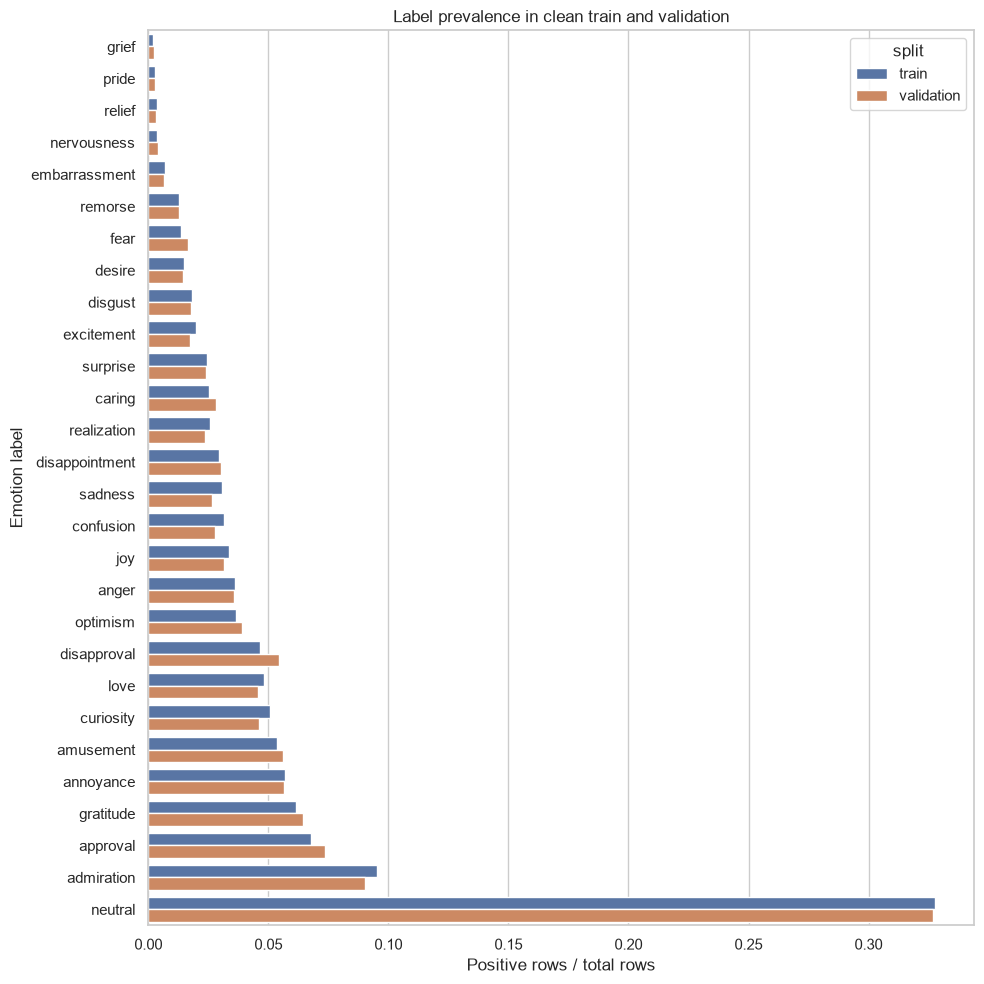

split,train,validation,absolute_gap
label,,,
disapproval,0.046579,0.054245,0.007666
approval,0.067703,0.073379,0.005676
admiration,0.095139,0.090098,0.005041
curiosity,0.050472,0.045885,0.004587
sadness,0.030546,0.026565,0.003981
confusion,0.031513,0.027680,0.003834
caring,0.025040,0.028237,0.003197
gratitude,0.061322,0.064276,0.002954
fear,0.013730,0.016534,0.002804


,split,label_cardinality,size,proportion
0,train,1,36308,0.836397
1,train,2,6541,0.150680
2,train,3,532,0.012255
3,train,4,28,0.000645
4,train,5,1,0.000023
5,validation,1,4509,0.837637
6,validation,2,805,0.149545
7,validation,3,62,0.011518
8,validation,4,7,0.001300


,sample_count,mean,median,maximum,multi_label_rate
split,,,,,
train,43410,1.177217,1.0,5,0.163603
validation,5383,1.176482,1.0,4,0.162363


In [5]:
label_stat_rows = []

for split_name, frame in analysis_frames.items():
    # tao 1 dict value la so luot xuat hien cua cac label id, key la label id
    label_counter = Counter(
        label_id
        for row_labels in frame["labels"]
        for label_id in row_labels
    )

    for label_id, label_name in enumerate(label_names):
        # so sample trong moi split mang label id do, lay ra du label_counter
        # prevalance la ty le sample mang id do tren tong so sample cua 1 split
        support = label_counter[label_id]

        label_stat_rows.append(
            {
                "split": split_name,
                "label_id": label_id,
                "label": label_name,
                "support": support,
                "prevalence": support / len(frame),
            }
        )

label_stats = pd.DataFrame(label_stat_rows)

train_label_stats = (
    label_stats[
        label_stats["split"] == "train"
    ]
    .sort_values("support", ascending=False)
    .reset_index(drop=True)
)

display(train_label_stats)

# bang the hien label/prevalance
label_order = list(
    train_label_stats.sort_values(
        "support",
        ascending=True,
    )["label"]
)

plt.figure(figsize=(10, 10))

sns.barplot(
    data=label_stats,
    x="prevalence",
    y="label",
    hue="split",
    order=label_order,
)

plt.title("Label prevalence in clean train and validation")
plt.xlabel("Positive rows / total rows")
plt.ylabel("Emotion label")
plt.tight_layout()
plt.show()

# chuyen label_stat sang dang table bang pivot
prevalence_table = label_stats.pivot(
    index="label",
    columns="split",
    values="prevalence",
)

# sort theo absolute cua prevalence
prevalence_table["absolute_gap"] = (
    prevalence_table["train"]
    - prevalence_table["validation"]
).abs()

display(
    prevalence_table.sort_values(
        "absolute_gap",
        ascending=False,
    )
)

combined_cardinality = pd.concat(
    [
        frame[["label_cardinality"]].assign(
            split=split_name
        )
        for split_name, frame in analysis_frames.items()
    ],
    ignore_index=True,
)

cardinality_distribution = (
    combined_cardinality
    .groupby(
        ["split", "label_cardinality"],
        as_index=False,
    )
    .size()
)

cardinality_distribution["proportion"] = (
    cardinality_distribution["size"]
    / cardinality_distribution.groupby(
        "split"
    )["size"].transform("sum")
)

display(cardinality_distribution)

cardinality_summary = (
    combined_cardinality
    .groupby("split")["label_cardinality"]
    .agg(
        sample_count="count",
        mean="mean",
        median="median",
        maximum="max",
    )
)

multi_label_rate = (
    combined_cardinality.assign(
        is_multi_label=(
            combined_cardinality[
                "label_cardinality"
            ] > 1
        )
    )
    .groupby("split")["is_multi_label"]
    .mean()
    .rename("multi_label_rate")
)

cardinality_summary = cardinality_summary.join(
    multi_label_rate
)

display(cardinality_summary)

#### Text length

Độ dài được đo bằng số từ phân tách bằng whitespace.


In [ ]:
text_length_data = pd.concat(
    [
        # dataframe duoc tao tu cot word_count tu frame (chi df moi co .assign)
        # roi sau do them (assign) them cot split_name, lenh nay them 1 df moi, khong sua df cu
        frame[["word_count"]].assign(
            split=split_name
        )
        # analysis_frames la dict chua key train va valid
        for split_name, frame in analysis_frames.items()
    ],
    # index danh lien tuc tu train qua valid, khong danh lai tu dau 
    ignore_index=True,
)


text_length_summary = (
    text_length_data
    .groupby("split")["word_count"]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(text_length_summary)

plot_upper_bound = int(
    text_length_data["word_count"].quantile(0.99)
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=text_length_data,
    x="word_count",
    hue="split",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
)

plt.xlim(0, plot_upper_bound)
plt.title(
    "Text-length distribution, displayed through p99"
)
plt.xlabel("Whitespace-separated word count")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print(
    "The chart is limited to p99 for readability. "
    "No rows were removed from the statistics."
)